## Static Test Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"

static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
static_veh, moving_veh = 1,2
all_test_files = get_test_files_and_survey("Static Test", "V2")[0]
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = None

In [2]:
def parse_single_test_data(test_file):
    _test_csv_base = "PostProcessed_" + os.path.splitext(os.path.basename(test_file))[0] + ".csv"
    _integ_csv_base = "Integrated_ABAB_COMBO-" + _test_csv_base.split("PostProcessed_")[1].split("-data-")[0] + ".csv"
    _integ_csv_dir = os.path.join(os.path.dirname(test_file), _integ_csv_base)
    
    # Processing Statistics
    base_folder = os.path.dirname(_integ_csv_dir)
    raw_name = os.path.basename(os.path.dirname(_integ_csv_dir))
    print("processing: " + raw_name)
    df = pd.read_csv(_integ_csv_dir, parse_dates=["Datetime Normalized"], index_col=["Datetime Normalized"])
    
    # Adding additional columns
    df["Test Name"] = raw_name
    df["Test Category"] = "Static Test"
    df["Aggregated Update Rate (Hz)"] = np.nan
    df['UWB Measured Instant Speed - Strict Pair (mph)'] = np.nan
    df['Aggregated Measured Speed (mph)'] = np.nan
    df['Test Start Time'] = pd.to_datetime(re.match('^[0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+[\-][0-9]+', 
                                                    raw_name)[0],
                                           format="%Y-%m-%d-%H-%M-%S")
    # Filter out distance measurement outliers 
    df, df_outlier = uwb_dist_outlier_identify(df, segments = 5)

    if df.empty:
        print(raw_name + " No Data")
        return None
    
    # Separting data frames by data-receiving vehicles 
    df = update_rate_by_strict_pairs(df)
    df = instant_spd_by_strict_pairs(df)
    
    df_static_veh_all_pairs = df[df['Initiating Vehicle'] == static_veh]
    df_moving_veh_all_pairs = df[df['Initiating Vehicle'] == moving_veh]
    df_static_veh_hz_aggregated_all_pairs = df[df['Initiating Vehicle'] == static_veh]
    df_moving_veh_hz_aggregated_all_pairs = df[df['Initiating Vehicle'] == moving_veh]

    df_static_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], inplace=True)
    df_moving_veh_hz_aggregated_all_pairs.sort_values(['Timestamp Norm (s)', 'Reporting Slave'], 
                                                      ascending=[True, True], inplace=True)
    
    binwidth = 20

    _raw_uwb_dist_static = df_static_veh_all_pairs["Correction Distance (mm)"]
    _raw_uwb_dist_moving = df_moving_veh_all_pairs["Correction Distance (mm)"]
    
    static_hist_disp_range = (_raw_uwb_dist_static.quantile(0.05), _raw_uwb_dist_static.quantile(0.95))
    static_hist_disp_range = None if np.nan in static_hist_disp_range else static_hist_disp_range
    static_bins = np.arange(min(_raw_uwb_dist_static), 
                            max(_raw_uwb_dist_static) + binwidth, 
                            binwidth) if not _raw_uwb_dist_static.empty else None
    
    moving_hist_disp_range = (_raw_uwb_dist_moving.quantile(0.05), _raw_uwb_dist_moving.quantile(0.95))
    moving_hist_disp_range = None if np.nan in moving_hist_disp_range else moving_hist_disp_range
    moving_bins = np.arange(min(_raw_uwb_dist_moving), 
                            max(_raw_uwb_dist_moving) + binwidth, 
                            binwidth) if not _raw_uwb_dist_moving.empty else None
    
    moving_ground_truth_df = None
    
    return {"df_static_veh_hz_aggregated_all_pairs":df_static_veh_hz_aggregated_all_pairs, 
            "df_moving_veh_hz_aggregated_all_pairs":df_moving_veh_hz_aggregated_all_pairs, 
            "df_outlier":df_outlier,
            "df_static_veh_all_pairs":df_static_veh_all_pairs,
            "df_moving_veh_all_pairs":df_moving_veh_all_pairs,
            "static_veh":static_veh,
            "moving_veh":moving_veh,
            "moving_ground_truth_df":moving_ground_truth_df,
            "static_hist_disp_range":static_hist_disp_range,
            "moving_hist_disp_range":moving_hist_disp_range,
            "static_bins":static_bins,
            "moving_bins":moving_bins
            }

In [3]:
def plot_single_test_data(raw_name):
    parsing_results = static_tests.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return
    # Unpack dataframes
    df_static_veh_hz_aggregated_all_pairs = parsing_results["df_static_veh_hz_aggregated_all_pairs"]
    df_moving_veh_hz_aggregated_all_pairs = parsing_results["df_moving_veh_hz_aggregated_all_pairs"]
    df_outlier = parsing_results["df_outlier"]
    static_veh = parsing_results["static_veh"]
    moving_veh = parsing_results["moving_veh"]
    df_static_veh_all_pairs = parsing_results["df_static_veh_all_pairs"]
    df_moving_veh_all_pairs = parsing_results["df_moving_veh_all_pairs"]
    static_hist_disp_range = parsing_results["static_hist_disp_range"]
    moving_hist_disp_range = parsing_results["moving_hist_disp_range"]
    static_bins = parsing_results["static_bins"]
    moving_bins = parsing_results["moving_bins"]
    
    ######################################################
    # Plotting individual tests
    ######################################################
    figure = plt.figure(figsize=(16, 9), dpi=150)
    static_surveyed_dist = df_static_veh_hz_aggregated_all_pairs["Surveyed Distance (mm)"].get(0, float('nan'))
    print("plotting: " + raw_name + " with Ground Truth Distance: " + str(round(static_surveyed_dist)) + "mm")
    titlename = "Static Test - " + raw_name.split("-static-v2-")[-1] + " - " + str(int(static_surveyed_dist)) + "mm"
    figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    
    # Unpack dataframes from dictionary
    plot_time_series_dist(figure=figure,
                          arrange_spec=221,
                          static_veh_df=df_static_veh_hz_aggregated_all_pairs,
                          moving_veh_df=df_moving_veh_hz_aggregated_all_pairs,
                          static_veh=static_veh,
                          moving_veh=moving_veh,
                          df_outlier=df_outlier,
                          surveyed_static_ground_truth_value=static_surveyed_dist,
                          moving_ground_truth_df=None,
                          fill=False,
                          resample=False, 
                          scatter=False)
    plot_upd_rate(figure=figure,
                  arrange_spec=223,
                  static_veh_df=df_static_veh_hz_aggregated_all_pairs, 
                  moving_veh_df=df_moving_veh_hz_aggregated_all_pairs, 
                  static_veh=static_veh, 
                  moving_veh=moving_veh, 
                  moving_ground_truth_df=None,
                  resample=True, 
                  scatter=False)
    
    plot_hist(  figure=figure,  
                arrange_spec=222, 
                veh_df=df_static_veh_all_pairs,
                bin_size=static_bins, 
                ground_truth_value=static_surveyed_dist,
                master_slave_mapping=static_master_slave_mapping,
                disp_range=static_hist_disp_range,
                hist_title="Hist - Vehicle {} (Static) against Vehicle {} (Mover)".format(static_veh, moving_veh))
    plot_hist(  figure=figure,  
                arrange_spec=224, 
                veh_df=df_moving_veh_all_pairs,
                bin_size=moving_bins, 
                ground_truth_value=static_surveyed_dist,
                master_slave_mapping=moving_master_slave_mapping,
                disp_range=moving_hist_disp_range, 
                hist_title="Hist - Vehicle {} (Mover) against Vehicle {} (Static)".format(moving_veh, static_veh))
    
    figure2 = plt.figure(figsize=(16, 9), dpi=150)
    plot_hist_hbar(figure=figure2,  
                   veh1_df=df_static_veh_all_pairs,
                   veh2_df=df_moving_veh_all_pairs,
                   veh1_bin_size=static_bins,
                   veh2_bin_size=moving_bins, 
                   ground_truth_value=static_surveyed_dist,
                   static_master_slave_mapping=static_master_slave_mapping,
                   moving_master_slave_mapping=moving_master_slave_mapping,                       
                   static_disp_range=static_hist_disp_range, 
                   moving_disp_range=moving_hist_disp_range, 
                   hist_title="Hist - Vehicle {} (Mover) against Vehicle {} (Static)".format(moving_veh, static_veh))
    plt.show()

## Parse and store the data for all the tests

In [4]:
static_tests = {}
for test in all_test_names:
    static_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"])

processing: 2021-05-25-08-47-11-static-v2-2
processing: 2021-05-25-08-52-15-static-v2-3
processing: 2021-05-25-08-55-36-static-v2-4
processing: 2021-05-25-09-08-13-static-v2-5
processing: 2021-05-25-09-12-21-static-v2-6
processing: 2021-05-25-09-16-22-static-v2-7
processing: 2021-05-25-09-20-18-static-v2-8
processing: 2021-05-25-09-23-50-static-v2-9
processing: 2021-05-25-09-27-41-static-v2-10
processing: 2021-05-25-09-31-46-static-v2-11
processing: 2021-05-25-09-35-42-static-v2-12
processing: 2021-05-25-09-39-16-static-v2-13
processing: 2021-05-25-09-42-52-static-v2-14


In [5]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

static_stats_dist_idx = []
moving_stats_dist_idx = []
for raw_name in all_test_names:
    parsing_results = static_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_static_veh_hz_aggregated_all_pairs = parsing_results["df_static_veh_hz_aggregated_all_pairs"]
    df_moving_veh_hz_aggregated_all_pairs = parsing_results["df_moving_veh_hz_aggregated_all_pairs"]
    df_outlier = parsing_results["df_outlier"]
    static_veh = parsing_results["static_veh"]
    moving_veh = parsing_results["moving_veh"]
    df_static_veh_all_pairs = parsing_results["df_static_veh_all_pairs"]
    df_moving_veh_all_pairs = parsing_results["df_moving_veh_all_pairs"]
    
    # Creating a separate dataframe to be indexed by surveyed distance. More useful for moving tests
    static_stats_dist_idx.append(df_static_veh_hz_aggregated_all_pairs.set_index("Surveyed Distance (mm)"))
    moving_stats_dist_idx.append(df_moving_veh_hz_aggregated_all_pairs.set_index("Surveyed Distance (mm)"))

    # Stats generate: Statistical overalls for individual tests
    df_stats_pairwise_static = generate_stats_pairwise(df_static_veh_hz_aggregated_all_pairs, 
                                                       static_veh, 
                                                       None, 
                                                       static_master_slave_mapping, 
                                                       static_main_master,
                                                       raw_name)
    df_stats_aggregated_static = generate_stats_aggregated(df_static_veh_hz_aggregated_all_pairs, 
                                                           static_veh, 
                                                           None,
                                                           raw_name)
    static_stats_list_pairwise.append(df_stats_pairwise_static)
    static_stats_list_aggregated.append(df_stats_aggregated_static)
    df_stats_pairwise_moving = generate_stats_pairwise(df_moving_veh_hz_aggregated_all_pairs, 
                                                       moving_veh, 
                                                       None, 
                                                       moving_master_slave_mapping, 
                                                       moving_main_master,
                                                       raw_name)
    df_stats_aggregated_moving = generate_stats_aggregated(df_moving_veh_hz_aggregated_all_pairs, 
                                                           moving_veh, 
                                                           None,
                                                           raw_name)
    moving_stats_list_pairwise.append(df_stats_pairwise_moving)
    moving_stats_list_aggregated.append(df_stats_aggregated_moving)

df_all_static_stats_pairwise_static_test = pd.concat(static_stats_list_pairwise, ignore_index=True)    
df_all_static_stats_aggregated_static_test = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated_static_test["Main Pair Counts"] = np.array(df_all_static_stats_pairwise_static_test[(df_all_static_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_static_stats_pairwise_static_test["Is Main Slave"]==True)]["Reporting Counts"])

df_all_moving_stats_pairwise_static_test = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated_static_test = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated_static_test["Main Pair Counts"] = np.array(df_all_moving_stats_pairwise_static_test[(df_all_moving_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_moving_stats_pairwise_static_test["Is Main Slave"]==True)]["Reporting Counts"])

df_all_static_stats_dist_idx_static_test = pd.concat(static_stats_dist_idx).dropna('index')
df_all_moving_stats_dist_idx_static_test = pd.concat(moving_stats_dist_idx).dropna('index')

## Static Test Overall Stats, Error v.s. Distance, Aggregated

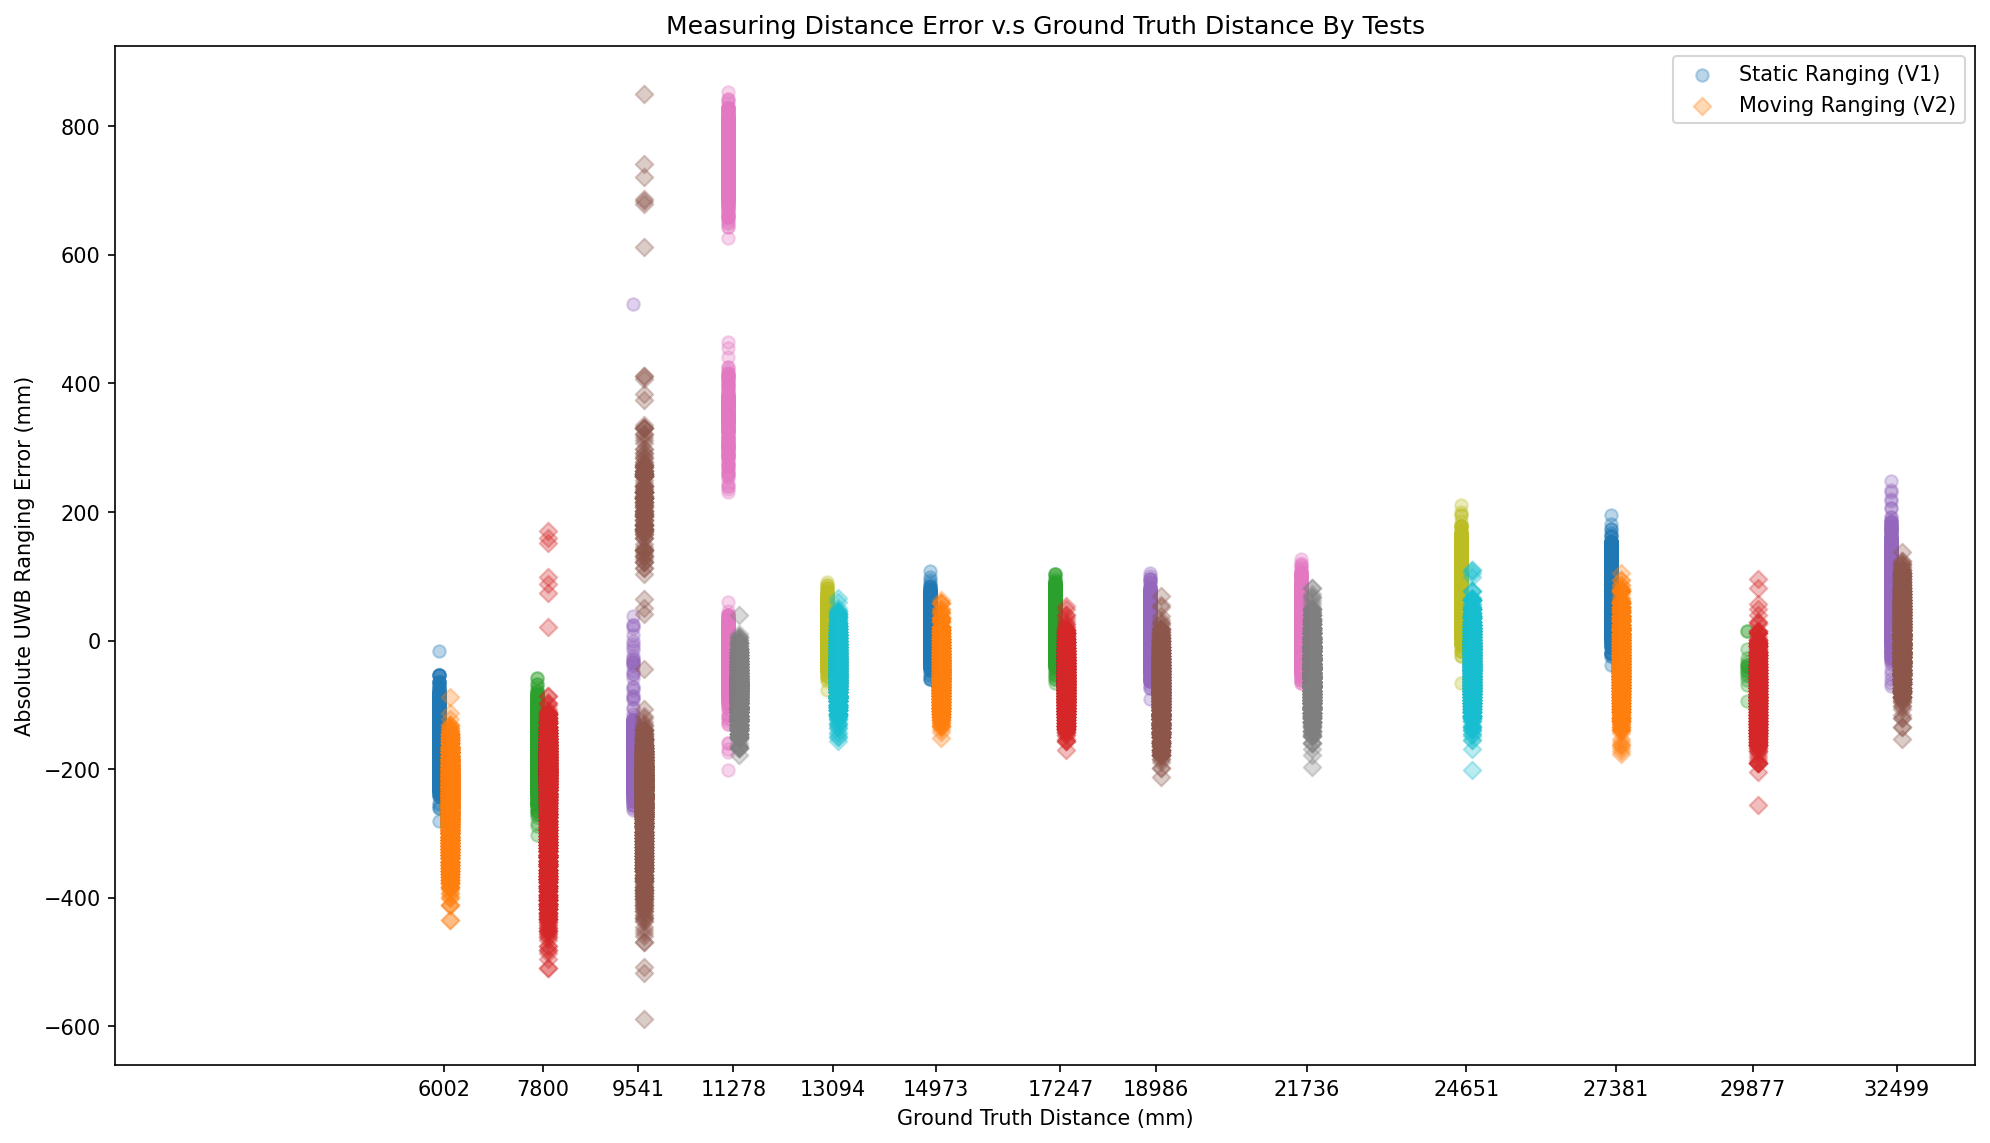

In [6]:
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_dist_idx_static_test["Test Name"].astype(str)
ground_truths = []
i = 0
for test in list(labels.unique()):
    # Aggregated datapoints - all pairs of Master/Slaves
    # Static Vehicle (V1) as a receiver
    _test_df_static = df_all_static_stats_dist_idx_static_test[df_all_static_stats_dist_idx_static_test["Test Name"] == test]
    # Moving Vehicle (V2) as a receiver
    _test_df_moving = df_all_moving_stats_dist_idx_static_test[df_all_moving_stats_dist_idx_static_test["Test Name"] == test]
    if i > 0:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, alpha=0.3, marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, alpha=0.3, marker="D")
    else:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, alpha=0.3, marker="o", label="Static Ranging (V1)")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, alpha=0.3, marker="D", label="Moving Ranging (V2)")        
    # Collect the ground truth measurements    
    ground_truths.append(_test_df_moving.index.unique()[0])
    i += 1 
    
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylabel("Absolute UWB Ranging Error (mm)")
ax.legend()
plt.show()

## Static Test Overall Stats, Error v.s. Distance, Main Master/Slave Pair Only

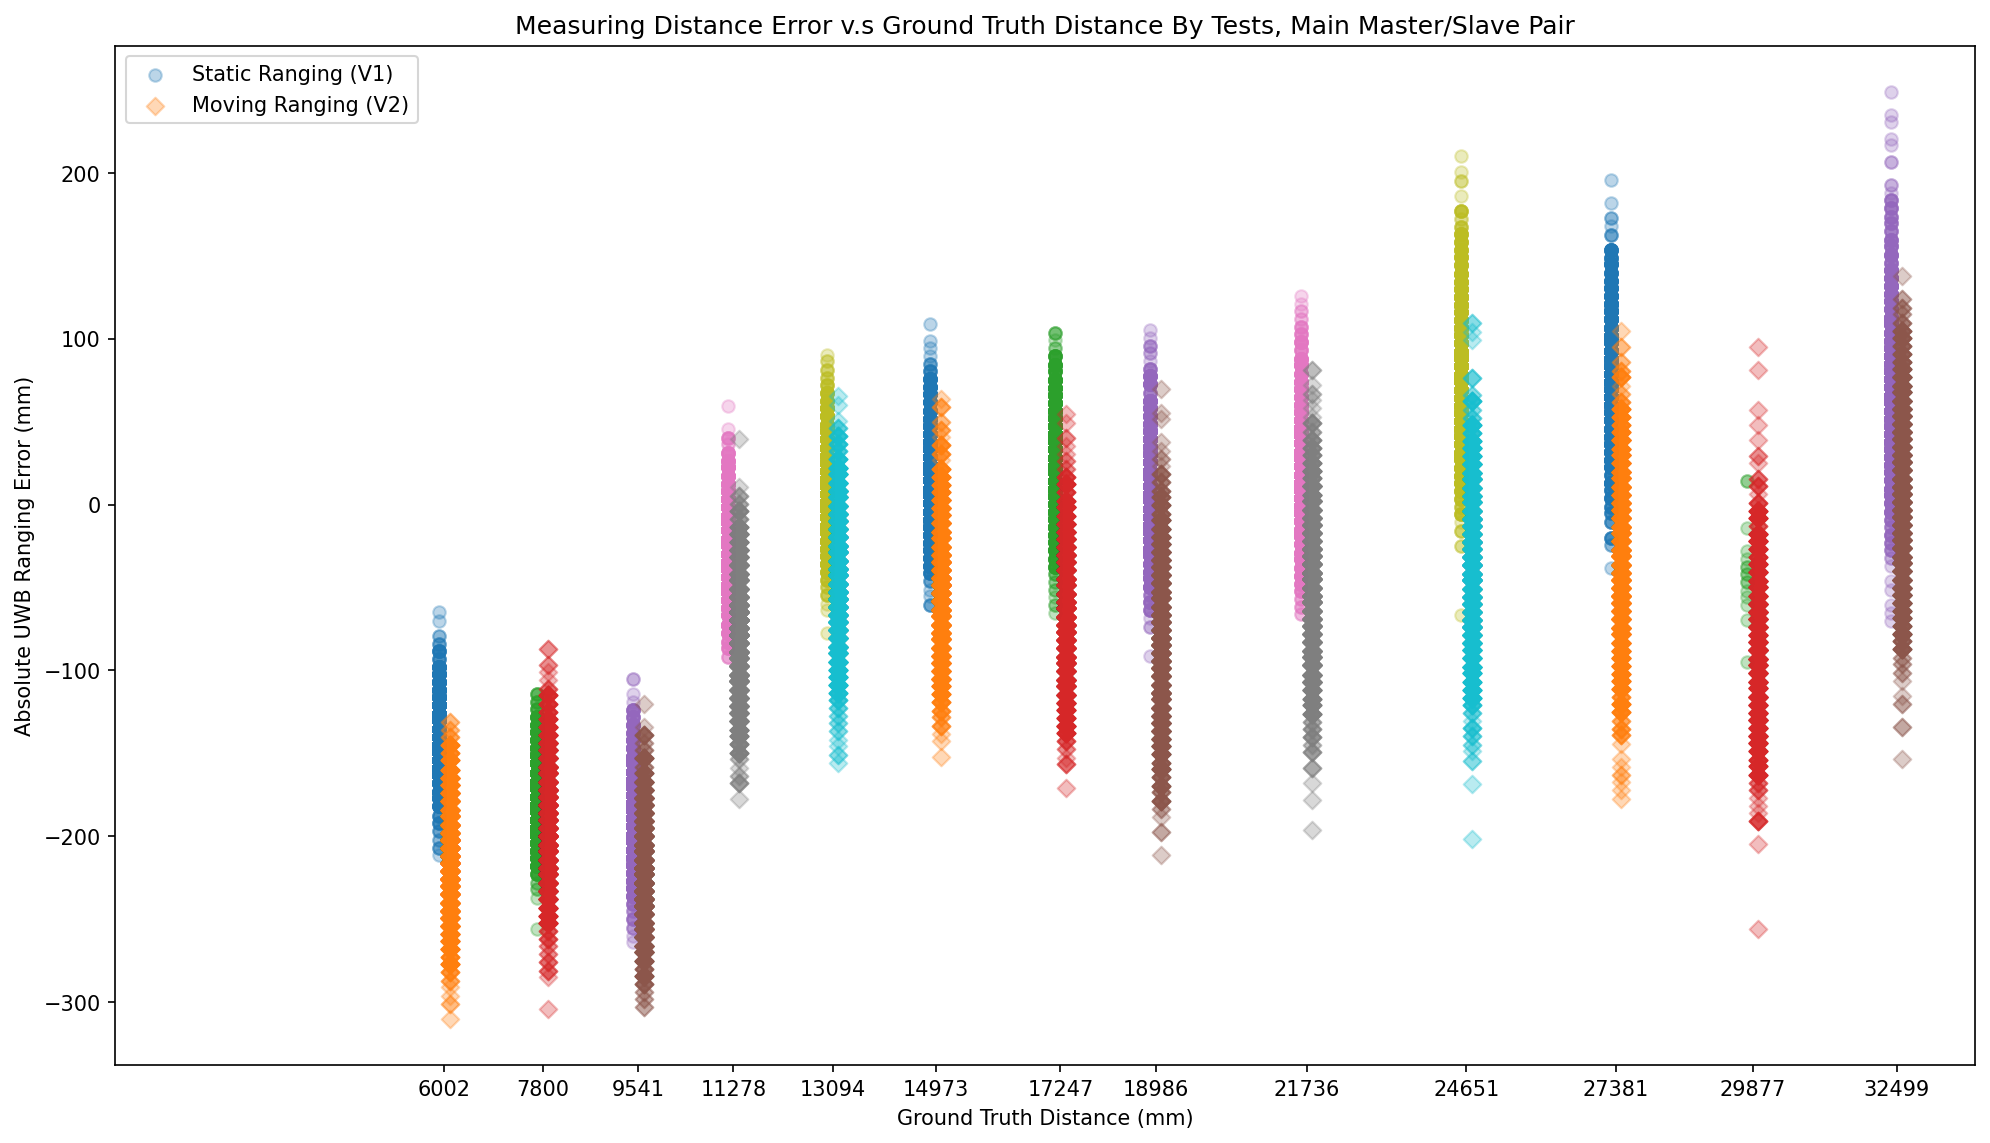

In [7]:
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
ax.set_title("Measuring Distance Error v.s Ground Truth Distance By Tests, Main Master/Slave Pair")
labels = df_all_static_stats_dist_idx_static_test["Test Name"].astype(str)
ground_truths = []
i = 0
for test in list(labels.unique()):
    # Aggregated datapoints - the main pair of Master/Slaves
    # Static Vehicle (V1) as a receiver
    _test_df_static = df_all_static_stats_dist_idx_static_test[
        (df_all_static_stats_dist_idx_static_test["Test Name"] == test) \
        & (df_all_static_stats_dist_idx_static_test["Initiating Master"] == static_main_master) \
        & (df_all_static_stats_dist_idx_static_test["Reporting Slave"] == static_master_slave_mapping[static_main_master][0])]
    # Moving Vehicle (V2) as a receiver
    _test_df_moving = df_all_moving_stats_dist_idx_static_test[
        (df_all_moving_stats_dist_idx_static_test["Test Name"] == test) \
        & (df_all_moving_stats_dist_idx_static_test["Initiating Master"] == moving_main_master) \
        & (df_all_moving_stats_dist_idx_static_test["Reporting Slave"] == moving_master_slave_mapping[moving_main_master][0])]
    if i > 0:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, marker="D")
    else:
        ax.scatter(_test_df_static.index-100, _test_df_static["Correction Distance (mm)"] - _test_df_static.index, 
                   alpha=0.3, label="Static Ranging (V1)", marker="o")
        ax.scatter(_test_df_moving.index+100, _test_df_moving["Correction Distance (mm)"] - _test_df_moving.index, 
                   alpha=0.3, label="Moving Ranging (V2)", marker="D")
    ground_truths.append(_test_df_moving.index.unique()[0])
    i += 1
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylabel("Absolute UWB Ranging Error (mm)")
ax.legend()
plt.show()

## Static Test Overall Stats, Connection Establishment Time  v.s. Distance

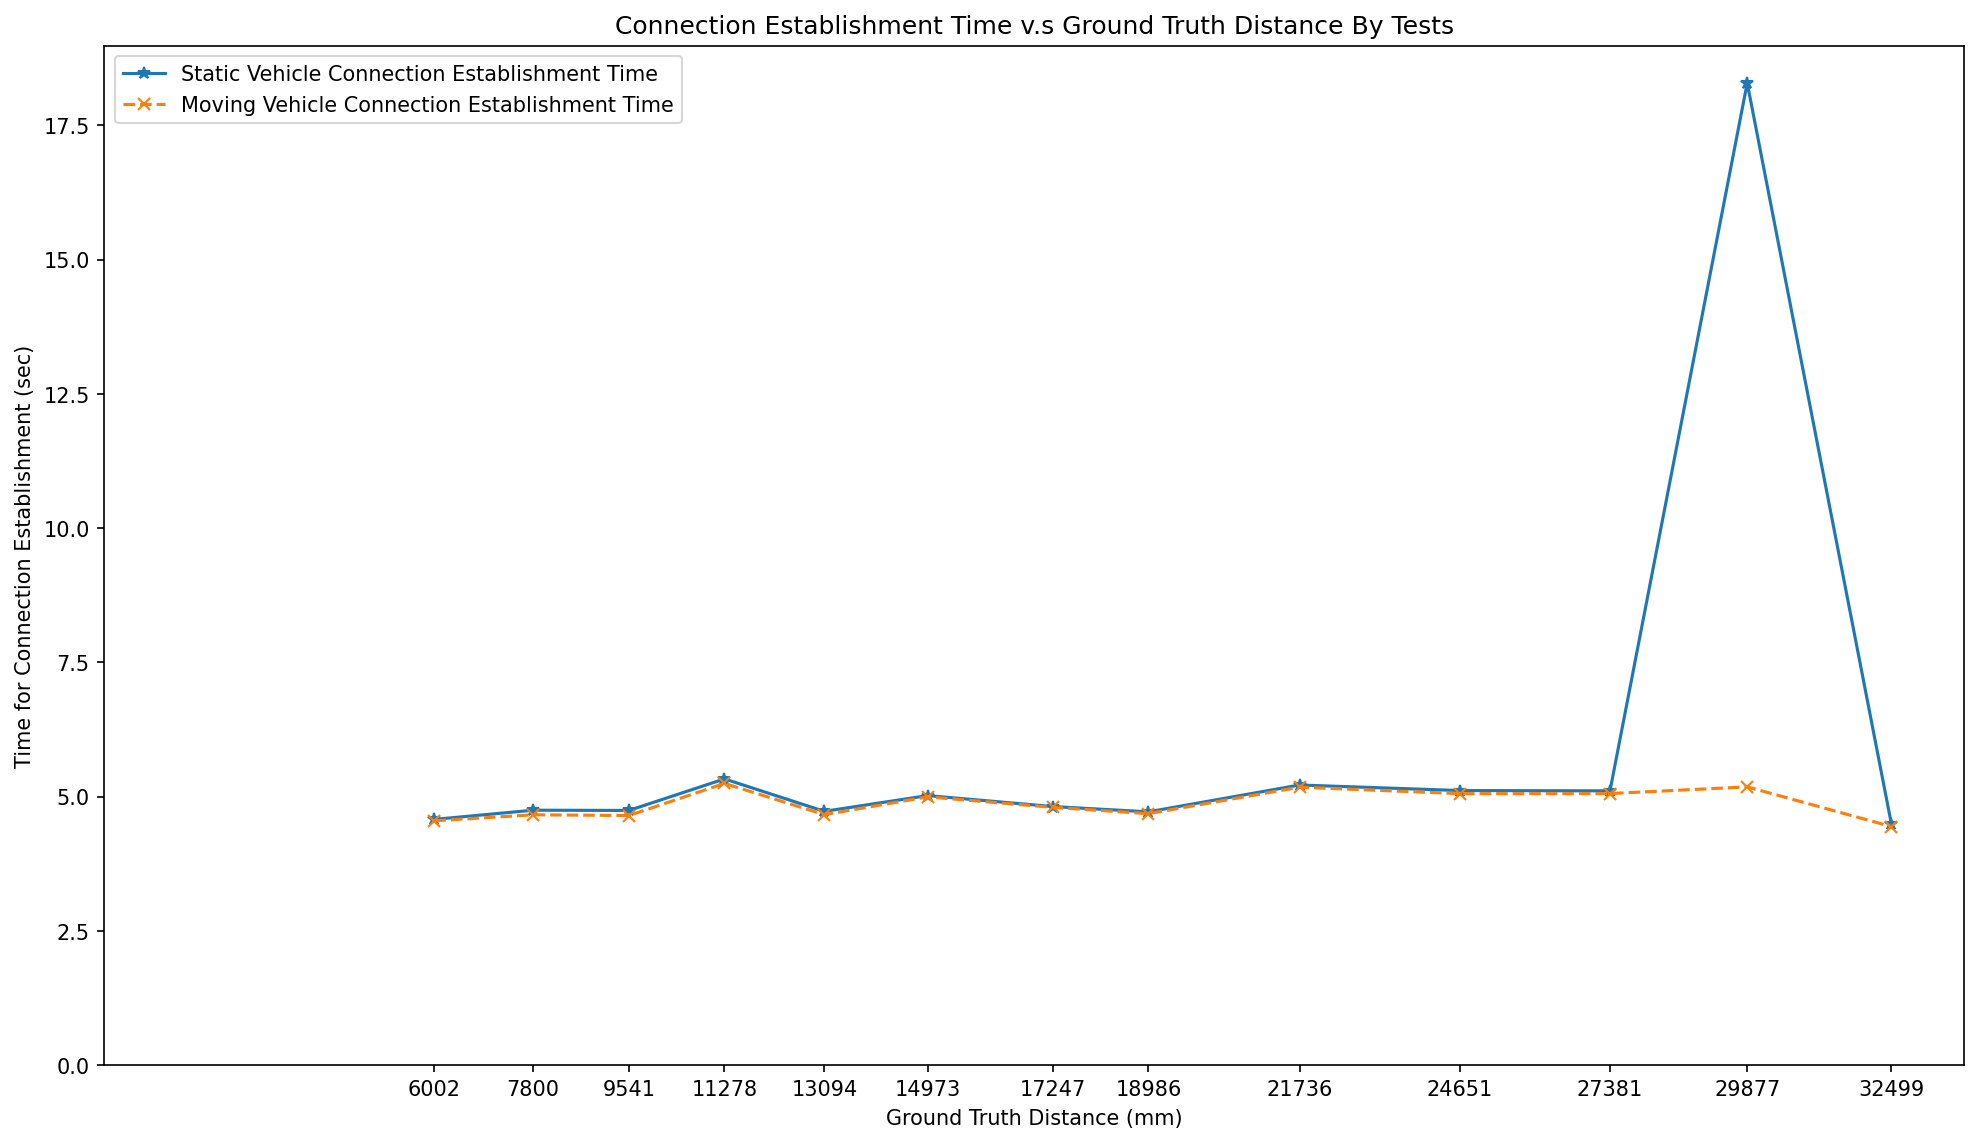

In [8]:
figure = plt.figure(figsize=(16, 9), dpi=150)
ax = figure.add_subplot(111)
ax.set_title("Connection Establishment Time v.s Ground Truth Distance By Tests")
labels = df_all_static_stats_aggregated_static_test["Test Name"].astype(str)
_x, _y = [], []
__x, __y = [], []
for test in list(labels.unique()):
    _test_df = df_all_static_stats_aggregated_static_test[df_all_static_stats_aggregated_static_test["Test Name"] == test]
    _est_time_sec = abs(_test_df['First Report Time'] - _test_df['Test Start Time'])
    _x.append(_test_df["Static Ground Truth (mm)"].unique()[0])
    _y.append(_est_time_sec.dt.total_seconds().unique()[0])
    
for test in list(labels.unique()):
    _test_df = df_all_moving_stats_aggregated_static_test[df_all_moving_stats_aggregated_static_test["Test Name"] == test]
    _est_time_sec = abs(_test_df['First Report Time'] - _test_df['Test Start Time'])
    __x.append(_test_df["Static Ground Truth (mm)"].unique()[0])
    __y.append(_est_time_sec.dt.total_seconds().unique()[0])
    
ax.plot(_x, _y, label="Static Vehicle Connection Establishment Time", marker="*")
ax.plot(__x, __y, label="Moving Vehicle Connection Establishment Time", marker="x", linestyle="--")
ax.set_xlabel("Ground Truth Distance (mm)")
ax.set_xticks(ground_truths)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_ylabel("Time for Connection Establishment (sec)")
ax.legend()
plt.show()

## Static Tests, Overall Statistics among All Tests (Aggregated)

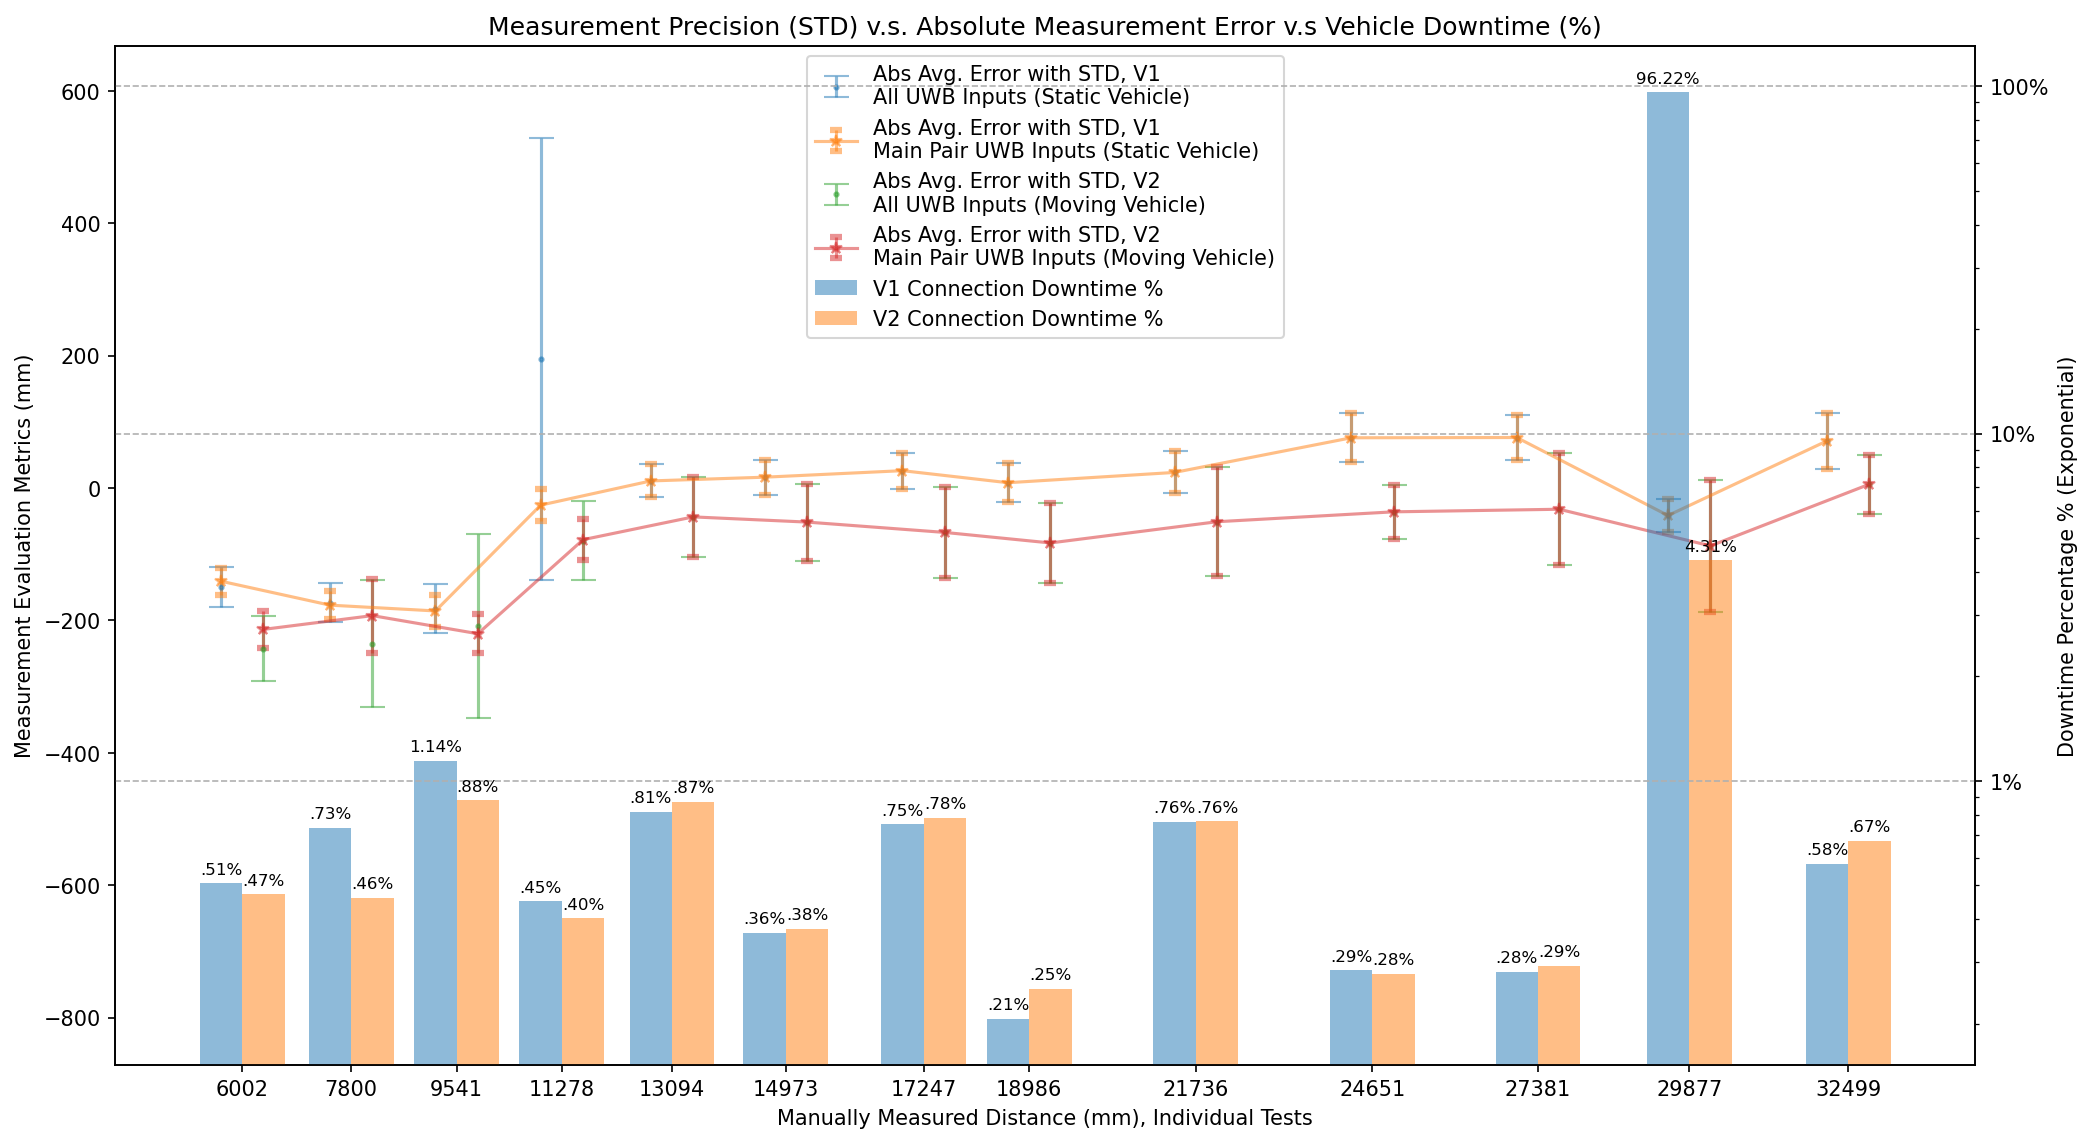

In [9]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width = 700
labels = df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Absolute Measurement Error v.s Vehicle Downtime (%)")
df_main_pair_static_veh_stats_static_test = df_all_static_stats_pairwise_static_test[(df_all_static_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_static_stats_pairwise_static_test["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_static_test = df_all_moving_stats_pairwise_static_test[(df_all_moving_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_moving_stats_pairwise_static_test["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]-width/2, 
                       y=df_all_static_stats_aggregated_static_test["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated_static_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_1_1 = ax.errorbar(x=df_main_pair_static_veh_stats_static_test["Static Ground Truth (mm)"]-width/2, 
                         y=df_main_pair_static_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated_static_test["Static Ground Truth (mm)"]+width/2, 
                       y=df_all_moving_stats_aggregated_static_test["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated_static_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(moving_veh))
errbar_2_1 = ax.errorbar(x=df_main_pair_moving_veh_stats_static_test["Static Ground Truth (mm)"]+width/2, 
                         y=df_main_pair_moving_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(moving_veh))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]-width/2,
                 df_all_static_stats_aggregated_static_test["Downtime Duration"] / df_all_static_stats_aggregated_static_test["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(static_veh), alpha=0.5)
rects2 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]+width/2, 
                 df_all_moving_stats_aggregated_static_test["Downtime Duration"] / df_all_moving_stats_aggregated_static_test["Operation Duration"], 
                 width, label='V{} Connection Downtime %'.format(moving_veh), alpha=0.5)

ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_yscale('log')
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects1, rects2], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), rects1.get_label(), rects2.get_label()], 
          loc='upper center')
plt.show()


## Static Tests, Overall Statistics among All UWB Devices

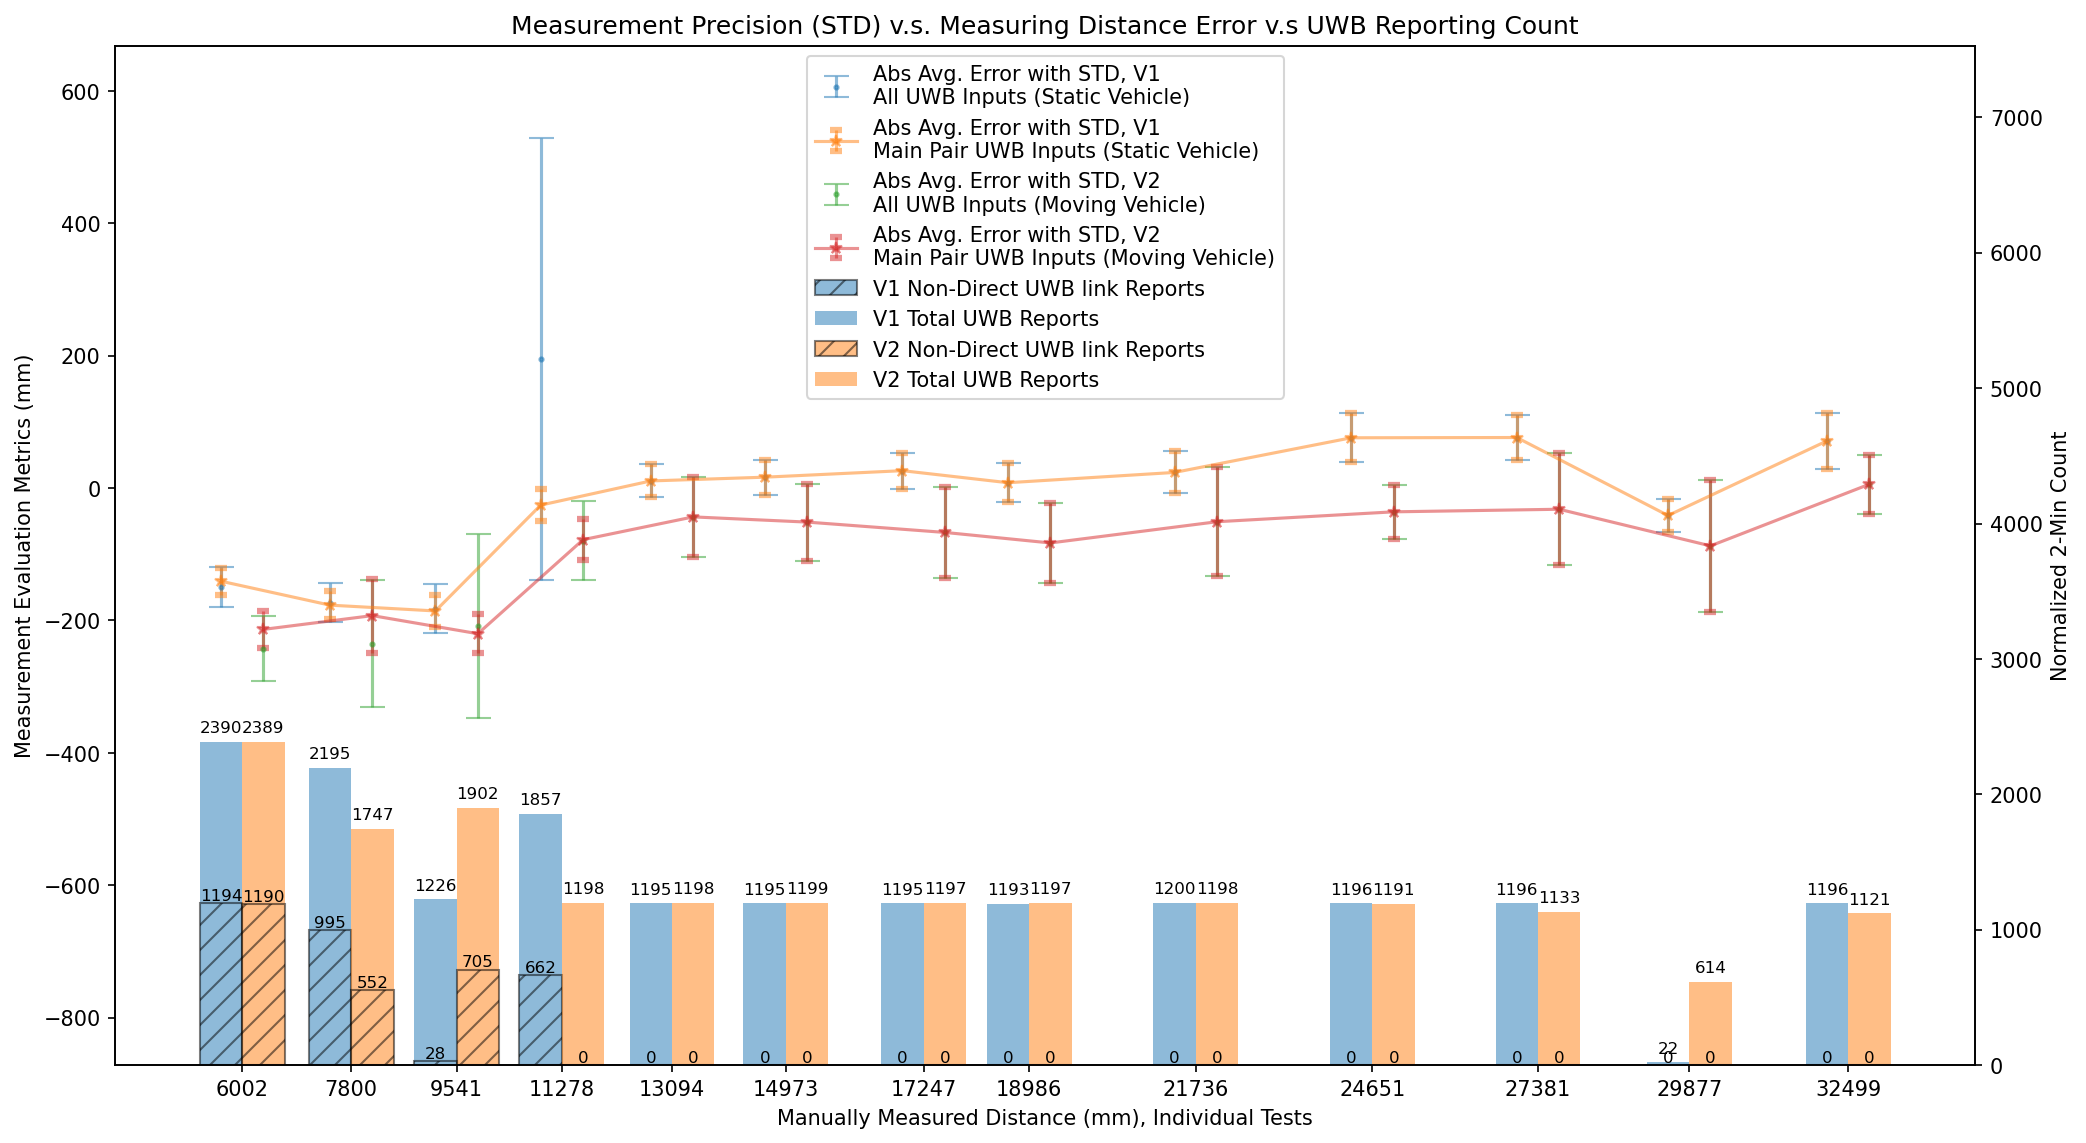

In [10]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=150)
width = 700
labels = df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s UWB Reporting Count")
df_main_pair_static_veh_stats_static_test = df_all_static_stats_pairwise_static_test[(df_all_static_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_static_stats_pairwise_static_test["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_static_test = df_all_moving_stats_pairwise_static_test[(df_all_moving_stats_pairwise_static_test["Is Main Master"]==True) & (df_all_moving_stats_pairwise_static_test["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]-width/2, 
                       y=df_all_static_stats_aggregated_static_test["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated_static_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_1_1 = ax.errorbar(x=df_main_pair_static_veh_stats_static_test["Static Ground Truth (mm)"]-width/2, 
                         y=df_main_pair_static_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(static_veh))
errbar_2 = ax.errorbar(x=df_all_moving_stats_aggregated_static_test["Static Ground Truth (mm)"]+width/2, 
                       y=df_all_moving_stats_aggregated_static_test["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated_static_test["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(moving_veh))
errbar_2_1 = ax.errorbar(x=df_main_pair_moving_veh_stats_static_test["Static Ground Truth (mm)"]+width/2, 
                         y=df_main_pair_moving_veh_stats_static_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_static_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(moving_veh))
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")
_ylim, _ylim_range = ax.get_ylim(), max(ax.get_ylim()) - min(ax.get_ylim())
_new_y_lim = (_ylim[0] - _ylim_range * 0.5, _ylim[1] + _ylim_range * 0.1)
ax.set_ylim(_new_y_lim)
ax2 = ax.twinx()

rects1 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]-width/2,
                (df_all_static_stats_aggregated_static_test["Main Pair Counts"]/df_all_static_stats_aggregated_static_test["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_static_stats_aggregated_static_test["Reporting Counts"] - df_all_static_stats_aggregated_static_test["Main Pair Counts"])/df_all_static_stats_aggregated_static_test["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(static_veh), alpha=0.5, color="C0")
rects0 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]-width/2,
                ((df_all_static_stats_aggregated_static_test["Reporting Counts"] - df_all_static_stats_aggregated_static_test["Main Pair Counts"])/df_all_static_stats_aggregated_static_test["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(static_veh), alpha=0.5, color="C0", hatch="//", edgecolor='k')

rects3 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]+width/2, 
                (df_all_moving_stats_aggregated_static_test["Main Pair Counts"]/df_all_moving_stats_aggregated_static_test["Operation Duration"]*120).astype("int"), 
                bottom=((df_all_moving_stats_aggregated_static_test["Reporting Counts"] - df_all_moving_stats_aggregated_static_test["Main Pair Counts"])/df_all_moving_stats_aggregated_static_test["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Total UWB Reports'.format(moving_veh), alpha=0.5, color="C1")
rects2 = ax2.bar(df_all_static_stats_aggregated_static_test["Static Ground Truth (mm)"]+width/2, 
                ((df_all_moving_stats_aggregated_static_test["Reporting Counts"] - df_all_moving_stats_aggregated_static_test["Main Pair Counts"])/df_all_moving_stats_aggregated_static_test["Operation Duration"]*120).astype("int"),
                width=width, label='V{} Non-Direct UWB link Reports'.format(moving_veh), alpha=0.5, color="C1", hatch="//", edgecolor='k')

ax2.set_ylabel("Normalized 2-Min Count")
ax2.bar_label(rects1, padding=3, fontsize=8)
ax2.bar_label(rects0, padding=0, fontsize=8)
ax2.bar_label(rects3, padding=3, fontsize=8)
ax2.bar_label(rects2, padding=0, fontsize=8)
_ylim, _ylim_range = ax2.get_ylim(), max(ax2.get_ylim()) - min(ax2.get_ylim())
_new_y_lim = (0, _ylim[1] + _ylim_range * 2)
ax2.set_ylim(_new_y_lim)
ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects0, rects1, rects2, rects3], 
          [errbar_1.get_label(),errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), rects0.get_label(), rects1.get_label(), rects2.get_label(), rects3.get_label()],
          loc='upper center')
plt.show()